Entrego evidencia de Asistencia de clase virtual del 8/4.

Termine el codigo, muestra los 3 graficos pedidos. Al de las señales en el tiempo y el histograma, los veo dentro de lo esperado. El grafico del espectro, se ve 'bien' en principio pero tengo que terminar de calcular la potencia de ambas maneras para verificar que este acertado.  

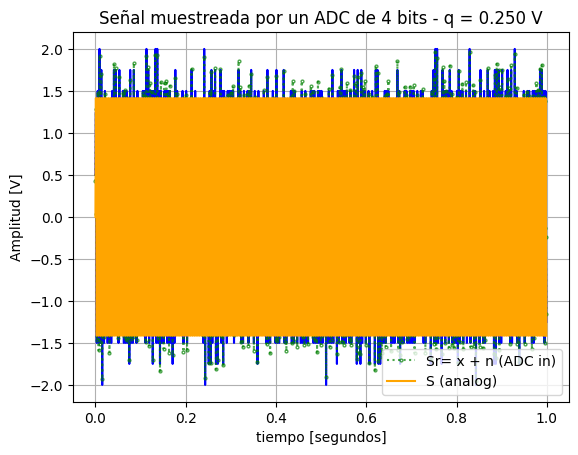

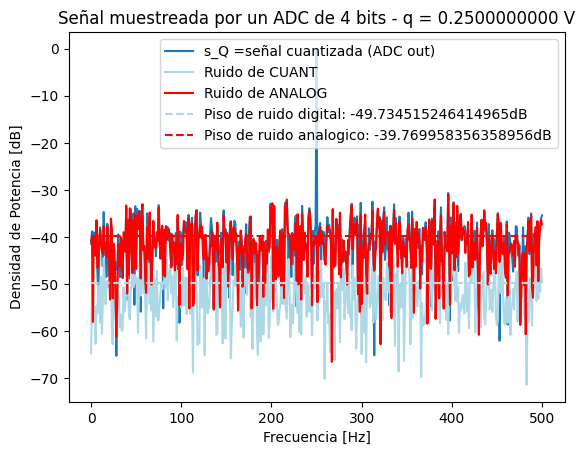

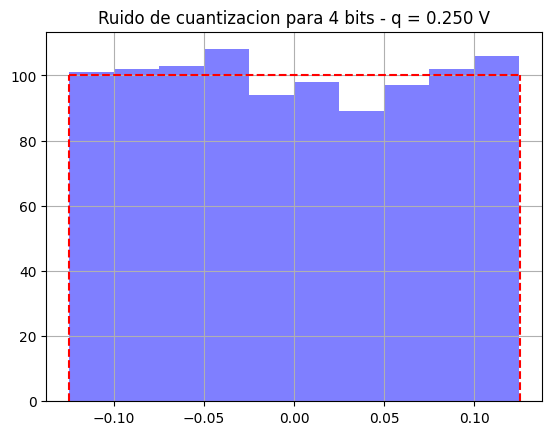

In [2]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt

#----------------------------------- Datos de la simulación---------------------------

N = 1000 # cantidad de muestras
fs =  N # frecuencia de muestreo (Hz)
ts = 1/fs # tiempo de muestreo
df = fs/N # resolución espectral (=1)
dc = 0
ph = 0

# Datos del ADC
Vf = 2      #Vf max = 2  y Vf min= -2, rango TOTAL=4
B = 4

# Definicion funciónes seno
def func_sen(Vmax=1, dc = dc, ff=1, ph=ph, nn = N, fs=fs):
    N= np.arange(nn)
    tt = N/fs    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc    
    return tt, xx
    
#%%
## DEFINICION SEÑAL
tt, xx = func_sen(ff = N/4, Vmax= np.sqrt(2)) # amp, dc, frec,p, N, fs
xx = xx.flatten()
# Normalizacion
xx=xx/np.std(xx)  
# Calculo de potencia, se espera P =1
Ps = np.mean(xx**2)

# POTENCIA
q = (2*Vf)/(2**B)# paso de cuantización de q Volts = (Vmax - Vmin)/2^B
Pq = q**2/12 # Watts  Pq

# escala de la potencia de ruido analógico
k =  10
Pn = Pq * k #potencia del ruido analogico    Pn
sigma = np.sqrt(Pn)

## RUIDO
nn=np.random.normal(0, sigma, N) #señal de ruido analogico
# media: 0, desvio: raiz de ruido analogico: ruido cuant * K=
incorr = sig.convolve(nn,nn)
sr = xx + nn # señal analógica de entrada al ADC (con ruido analógico)

## RUIDO CUANTIZADO
srq = np.round(sr/q)*q
#Ej: si q=0.1 y sr=0,43, hago 0.43/0.1=4.3, redondeo para -> 4, entonces hago4*(q=0.1)=0.4
nq =  srq-sr # señal de ruido de cuantización || aca se hace la diferencia entre la señal y la señal cuantizada (ambas con ruido)

# CALCULO FFT + VECT FRECS
#Uso la fft aplicada sobre señales en el tiempo para verlas en el espectro 
ft_SR =  1/N*np.fft.fft(sr)          #sr: analogica con ruido 
ft_Srq = 1/N*np.fft.fft(srq)         #srq: cuantizada
ft_As =  1/N*np.fft.fft(xx)          #As: senoidal limpia
ft_Nq =  1/N*np.fft.fft(nq)          #Nq: ruido cuantizado= sr-srq
ft_Nn =  1/N*np.fft.fft(nn)          #Nn: ruido analogico 

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)   #vector de frecs desde 0 hasta fs-1 (en este caso pq N=fs) 
bfrec = ff <= fs/2    #bfrec: filtro booleano que te deja solo las frecs hasta fs/2 = frc de nyquist

#Nnq_mean = np.sum(np.abs(ft_Nq)**2)  
#nNn_mean = np.sum(np.abs(ft_Nn)**2)
Nnq_mean = np.mean(np.abs(ft_Nq)**2)  
nNn_mean = np.mean(np.abs(ft_Nn)**2)

#%%
# GRAFICOS 
#GRAF 1: SEÑAL + RUIDO
plt.figure()
plt.plot(tt, srq, color='blue', label='')
plt.plot(tt, sr, color='g',alpha= 0.7, ls='dotted',marker='o',markerfacecolor='none',markeredgecolor='g',markersize=2, label='Sr= x + n (ADC in)')
plt.plot(tt, xx, color='orange', label='S (analog)')
plt.title('Señal muestreada por un ADC de {:d} bits - q = {:3.3f} V'.format(B, q) )
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid(True)
plt.show()
  
## GRAF 2: ESPERCTRO 
piso_ruido_analogico = 10* np.log10(2* nNn_mean)
piso_ruido_digital = 10* np.log10(2* Nnq_mean)
ruido_dig = 10* np.log10(2*np.var(nq))
# ruido_cuant = 10*np.log10(Pq)
# ruido_ana = 10*np.log10(Pn)

piso_ruido_digital_fft = 10*np.log10(2* Nnq_mean)
piso_ruido_digital_var = 10*np.log10(2* np.var(nq))

                          
plt.figure()
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2), label='s_Q =señal cuantizada (ADC out)' )
plt.plot(ff[bfrec], 10*np.log10(2*np.abs(ft_Nq[bfrec])**2), label='Ruido de CUANT', color='lightblue' )
plt.plot(ff[bfrec], 10*np.log10(2*np.abs(ft_Nn[bfrec])**2), label='Ruido de ANALOG', color='r' )
plt.hlines(y= piso_ruido_digital , xmin=0, xmax=500, colors='lightblue', linestyles='--',  label= f'Piso de ruido digital: {piso_ruido_digital}dB')
plt.hlines(y= piso_ruido_analogico, xmin=0, xmax=500, colors='r', linestyles='--',  label= f'Piso de ruido analogico: {piso_ruido_analogico}dB')
plt.title('Señal muestreada por un ADC de {:d} bits - q = {:3.10f} V'.format(B, q) )
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
axes_hdl = plt.gca()
axes_hdl.legend()
#plt.ylim(-120, 0)
plt.show()


## GRAF 3: HISTOGRAMA 
bins =10
xlim = q/2
ylim = N / bins
plt.figure()
plt.title('Ruido de cuantizacion para {:d} bits - q = {:3.3f} V'.format(B, q) )
plt.hist(nq, bins=bins, color='blue', alpha=0.5)
plt.hlines(y= ylim, xmin=-xlim, xmax=xlim, colors='r', linestyles='--')
plt.vlines(x=-xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.vlines(x=xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.grid(True)
plt.show()